# Notebook 1 : Exploration et préparation des données

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
population= pd.read_csv('Population_2000_2018.csv', sep=';', usecols=['Zone','Année','Unité','Valeur'])
dispo_alimentaire= pd.read_csv('DisponibiliteAlimentaire_2017.csv', sep=';', usecols=['Zone','Élément','Produit','Unité','Valeur'])
stabilite_politique= pd.read_csv('Stabilité_politique.csv', sep=';')
pib_hab= pd.read_csv('PIB_par_hab.csv', sep=';')
ipl= pd.read_csv('Indice_performance_logistique.csv', sep=';')
conso_energie_renouvelable= pd.read_csv('conso_energie_renouvelable.csv', sep=';')
acces_elec= pd.read_csv('Acces_electricite.csv', sep=';')
correspondance_pays= pd.read_csv('correspondance_pays.csv', sep=';')

### 1. Nettoyage des tables

#### 1.0 Fichier correspondance_pays

In [3]:
correspondance_pays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Code zone (ISO3)  210 non-null    object
 1   pays_FAO          210 non-null    object
 2   pays_BM_fr        207 non-null    object
 3   pays_BM_en        207 non-null    object
dtypes: object(4)
memory usage: 6.7+ KB


In [4]:
correspondance_pays.head()

,Code zone (ISO3),pays_FAO,pays_BM_fr,pays_BM_en
0,AFG,Afghanistan,Afghanistan,Afghanistan
1,ZAF,Afrique du Sud,Afrique du Sud,South Africa
2,ALB,Albanie,Albanie,Albania
3,DZA,Algérie,Algérie,Algeria
4,DEU,Allemagne,Allemagne,Germany


In [5]:
#verification des doublons
correspondance_pays['Code zone (ISO3)'].duplicated().sum()

0

In [6]:
#j'affiche les observations manquantes 
print(correspondance_pays[correspondance_pays.isna().any(axis=1)])

    Code zone (ISO3)    pays_FAO pays_BM_fr pays_BM_en
7                AIA    Anguilla        NaN        NaN
84               COK   Îles Cook        NaN        NaN
128              MSR  Montserrat        NaN        NaN


In [7]:
#Suppression des territoires non souverains sans données Banque mondiale exploitables
correspondance_pays= correspondance_pays.dropna()

Les territoires d’Anguilla, des Îles Cook et de Montserrat ont été exclus de l’analyse car ils ne disposent pas de données complètes dans les bases de la Banque mondiale. Il s’agit de territoires non souverains ou à statut particulier, dont le poids démographique et économique est marginal. Leur exclusion permet de garantir la cohérence et la robustesse des analyses multivariées sans affecter la représentativité globale de l’étude.

In [8]:
#Renommage de la colonne "Code zone (ISO3)":
correspondance_pays= correspondance_pays.rename(columns={"Code zone (ISO3)":"pays_code"})

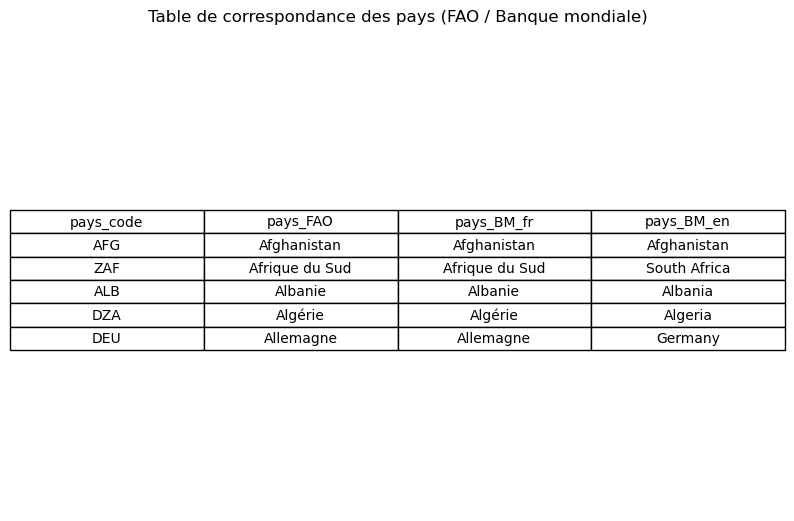

In [9]:
# Sélection d’un extrait 
df_table = correspondance_pays.head(5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

table = ax.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.title("Table de correspondance des pays (FAO / Banque mondiale)", pad=20)

plt.savefig(
    "table_correspondance_pays.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 1.1 Fichier population

In [10]:
population.head(5)

,Zone,Année,Unité,Valeur
0,Afghanistan,2000,1000 personnes,20779.953
1,Afghanistan,2001,1000 personnes,21606.988
2,Afghanistan,2002,1000 personnes,22600.770
3,Afghanistan,2003,1000 personnes,23680.871
4,Afghanistan,2004,1000 personnes,24726.684


In [11]:
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    4411 non-null   object 
 1   Année   4411 non-null   int64  
 2   Unité   4411 non-null   object 
 3   Valeur  4411 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 138.0+ KB


In [12]:
# je filtre sur l'année 2017 
population= population[population['Année'] == 2017]

In [13]:
# je multiplie la valeur par 1000 pour avoir le nombre d'habitants 
population['Valeur'] = (population['Valeur'] * 1000).astype(int)

In [14]:
#je verifie les doublons dans la colonne Zone 
doublons_pop_zone = population[population['Zone'].duplicated(keep=False)]

nb_doublons = doublons_pop_zone.shape[0]

if nb_doublons > 0:
    print(f"Il y a {nb_doublons} doublons dans la colonne Zone de population.")
else:
    print("Il n'y a pas de doublons dans la colonne Zone de population.")

Il n'y a pas de doublons dans la colonne Zone de population.


In [15]:
#je supprime les colonnes inutiles a l'analyse: 'Année' et 'Unité'  et renomme les autres
population =( 
                population.drop(columns=['Année','Unité']) 
                          .rename(columns={'Zone':'pays_FAO' , 'Valeur':'nb_hab'}) 
               )

In [16]:
population.info()

<class 'pandas.core.frame.DataFrame'>
Index: 236 entries, 17 to 4409
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   pays_FAO  236 non-null    object
 1   nb_hab    236 non-null    int32 
dtypes: int32(1), object(1)
memory usage: 4.6+ KB


Parmi les entités sans code ISO3 après jointure, seules la Turquie et les Pays-Bas correspondent à des pays souverains disposant de données complètes dans les bases internationales. Ces deux cas ont fait l’objet d’une correction manuelle de libellé afin d’assurer leur intégration. Les autres entités correspondent à des territoires non souverains ou à statut particulier et ont été exclues.
Je retire donc ma jointure, les modifie manuellement et la refais.

In [17]:
# je les modifie donc manuellement: 
population['pays_FAO'] = population['pays_FAO'].replace({
    'Pays-Bas': 'Pays-Bas (Royaume des)',
    'Turquie': 'Türkiye'
})

In [18]:
# Je joins population et correspondance pays pour obtenir pays_code dans le DF population
population =( population.merge(correspondance_pays, how='left', on='pays_FAO')
                        .drop(columns=['pays_BM_fr','pays_BM_en'])
                         .dropna()
            )

In [19]:
#Je place la clé pays_code en premiere colonne pour faciliter la lecture et pour les futures opérations de jointures
population = population[['pays_code', 'pays_FAO', 'nb_hab']]

In [20]:
population.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 0 to 235
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pays_code  206 non-null    object
 1   pays_FAO   206 non-null    object
 2   nb_hab     206 non-null    int32 
dtypes: int32(1), object(2)
memory usage: 5.6+ KB


Parmi les éléments FAOSTAT disponibles, seuls ceux décrivant la production, les échanges internationaux et la consommation finale ont été conservés. Les usages intermédiaires et indicateurs nutritionnels ont été exclus car non pertinents pour une étude de marché à l’export.


#### 1.2 Fichier stabilite_politique 

In [21]:
stabilite_politique.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 3 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Country Name                                           264 non-null    object 
 1   Country Code                                           266 non-null    object 
 2   Political Stability and Absence of Violence/Terrorism  205 non-null    float64
dtypes: float64(1), object(2)
memory usage: 6.4+ KB


In [22]:
stabilite_politique.head(5)

,Country Name,Country Code,Political Stability and Absence of Violence/Terrorism
0,Aruba,ABW,1.313846
1,NaN,AFE,NaN
2,Afghanistan,AFG,-2.794976
3,NaN,AFW,NaN
4,Angola,AGO,-0.387895


In [23]:
#j'affiche toutes les lignes ayant au moins une donnée manquante: 
stabilite_politique[stabilite_politique.isna().any(axis=1)]

,Country Name,Country Code,Political Stability and Absence of Violence/Terrorism
1,NaN,AFE,NaN
3,NaN,AFW,NaN
7,Le monde arabe,ARB,NaN
36,Europe centrale et les pays baltes,CEB,NaN
38,Îles Anglo-Normandes,CHI,NaN
...,...,...,...
240,Asie du Sud (BIRD et IDA),TSA,NaN
241,Afrique subsaharienne (BIRD et IDA),TSS,NaN
249,"Revenu intermédiaire, tranche supérieure",UMC,NaN
255,Îles Vierges britanniques,VGB,NaN


In [24]:
#ils correspondent a des regroupements et pas des pays souverains donc inutiles pour l'analyse
stabilite_politique= stabilite_politique.dropna()

In [25]:
#renommer les colonnes 
stabilite_politique= stabilite_politique.rename(columns={'Country Name':'pays_BM_fr' , 'Country Code':'pays_code','Political Stability and Absence of Violence/Terrorism':'stabilite_pol' })

#arrondi des valeurs de stabilite popilique 2 chiffres après la virgule 
stabilite_politique['stabilite_pol'] = stabilite_politique['stabilite_pol'].round(2)

#placement des colonnes avec pays_code au début
stabilite_politique= stabilite_politique[['pays_code', 'pays_BM_fr', 'stabilite_pol']]

#### 1.3 Fichier pib_hab

In [26]:
pib_hab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country Name        266 non-null    object 
 1   Country Code        266 non-null    object 
 2   GDP per capita ($)  259 non-null    float64
dtypes: float64(1), object(2)
memory usage: 6.4+ KB


In [27]:
pib_hab.head()

,Country Name,Country Code,GDP per capita ($)
0,Aruba,ABW,28440.041688
1,Africa Eastern and Southern,AFE,1528.104224
2,Afghanistan,AFG,525.469771
3,Africa Western and Central,AFW,1574.230564
4,Angola,AGO,2790.718869


In [28]:
#renommage des noms des colonnes
pib_hab = pib_hab.rename(columns={
    'Country Name': 'pays_BM_en',
    'Country Code': 'pays_code',
    'GDP per capita ($)': 'pib_par_hab($)'
})

In [29]:
#placement correct des colonnes
pib_hab= pib_hab[['pays_code','pays_BM_en','pib_par_hab($)']]

j'ai des agregats car ce fichier provient de la Banque Mondiale donc je vais les exclure en conservant uniquement les entités présentes dans le référentiel de correspondance_pays, garantissant ainsi l’alignement des unités d’analyse entre les différentes sources.

In [30]:
#je ne conserve que les pays appartenant aux pays de correspondance_pays
codes_pays = set(correspondance_pays['pays_code'])
pib_hab = pib_hab[pib_hab['pays_code'].isin(codes_pays)]

In [31]:
#arrondi a l'entier du pib_par_hab($)
pib_hab['pib_par_hab($)'] = pib_hab['pib_par_hab($)'].round(0).astype('Int64')

#### 1.4 Fichier IPL Indice de Performance Logistique 

In [32]:
ipl.head()

,Country Name,Country Code,Indice de performance logistique
0,Aruba,ABW,NaN
1,NaN,AFE,"2,49"
2,Afghanistan,AFG,"1,95"
3,NaN,AFW,"2,41"
4,Angola,AGO,"2,05"


In [33]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 3 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Country Name                      264 non-null    object
 1   Country Code                      266 non-null    object
 2   Indice de performance logistique  207 non-null    object
dtypes: object(3)
memory usage: 6.4+ KB


In [34]:
#renommage des colonnes
ipl= ipl.rename(columns={'Country Name':'pays_BM_fr' , 'Country Code':'pays_code' , 'Indice de performance logistique':'ind_perf_logistique'})

In [35]:
# pour rappel: codes_pays = set(correspondance_pays['pays_code'])
ipl = ipl[ipl['pays_code'].isin(codes_pays)]

In [36]:
#remplacement des ',' en '.' de ind_perf_logistique
ipl['ind_perf_logistique'] = ipl['ind_perf_logistique'].str.replace(',', '.', regex=False)
#changement du type de ind_perf_logistique en float
ipl['ind_perf_logistique'] = ipl['ind_perf_logistique'].astype(float)

In [37]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 207 entries, 0 to 265
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pays_BM_fr           207 non-null    object 
 1   pays_code            207 non-null    object 
 2   ind_perf_logistique  159 non-null    float64
dtypes: float64(1), object(2)
memory usage: 6.5+ KB


#### 1.5 Fichier conso_energie_renouvelable

In [38]:
conso_energie_renouvelable.head()

,Country Name,Country Code,Consommation d’énergies renouvelables (% de la consommation totale d’énergie)
0,Aruba,ABW,"6,8"
1,NaN,AFE,"61,43"
2,Afghanistan,AFG,"19,5"
3,NaN,AFW,"76,1"
4,Angola,AGO,"52,5"


In [39]:
conso_energie_renouvelable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 3 columns):
 #   Column                                                                         Non-Null Count  Dtype 
---  ------                                                                         --------------  ----- 
 0   Country Name                                                                   264 non-null    object
 1   Country Code                                                                   266 non-null    object
 2   Consommation d’énergies renouvelables (% de la consommation totale d’énergie)  260 non-null    object
dtypes: object(3)
memory usage: 6.4+ KB


In [40]:
# renommage des colonnes 
conso_energie_renouvelable= conso_energie_renouvelable.rename(columns={'Country Name':'pays_BM_fr' ,
                                                                       'Country Code' :'pays_code' , 
                                                                      'Consommation d’énergies renouvelables (% de la consommation totale d’énergie)' : 'conso_energie'})                                                                

In [41]:
#positionnement des colonnes 
conso_energie_renouvelable= conso_energie_renouvelable[['pays_code','pays_BM_fr','conso_energie']]

In [42]:
#je ne conserve que les observations dont les pays ne sont pas des agrégats 
# pour rappel: codes_pays = set(correspondance_pays['pays_code'])
conso_energie_renouvelable = conso_energie_renouvelable[conso_energie_renouvelable['pays_code'].isin(codes_pays)]

In [43]:
conso_energie_renouvelable.info()

<class 'pandas.core.frame.DataFrame'>
Index: 207 entries, 0 to 265
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pays_code      207 non-null    object
 1   pays_BM_fr     207 non-null    object
 2   conso_energie  205 non-null    object
dtypes: object(3)
memory usage: 6.5+ KB


In [44]:
#remplacement des ',' en '.' de conso_energie
conso_energie_renouvelable['conso_energie'] = conso_energie_renouvelable['conso_energie'].str.replace(',', '.', regex=False)
#changement du type de coso_energie en float
conso_energie_renouvelable['conso_energie'] = conso_energie_renouvelable['conso_energie'].astype(float)

#### 1.6 Fichier acces_elec

In [45]:
acces_elec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 3 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Country Name                     264 non-null    object
 1   Country Code                     266 non-null    object
 2   Accès électricité (%population)  263 non-null    object
dtypes: object(3)
memory usage: 6.4+ KB


In [46]:
acces_elec.head()

,Country Name,Country Code,Accès électricité (%population)
0,Aruba,ABW,100
1,NaN,AFE,"40,22"
2,Afghanistan,AFG,"97,7"
3,NaN,AFW,"48,9"
4,Angola,AGO,"42,9"


In [47]:
# renommage des colonnes 
acces_elec= acces_elec.rename(columns={'Country Name':'pays_BM_fr' ,'Country Code' :'pays_code' , 'Accès électricité (%population)':'acces_electricite' }) 

In [48]:
#positionnement des colonnes
acces_elec= acces_elec[['pays_code','pays_BM_fr','acces_electricite']]

In [49]:
#je ne conserve que les observations dont les pays ne sont pas des agrégats 
# pour rappel: codes_pays = set(correspondance_pays['pays_code'])
acces_elec = acces_elec[acces_elec['pays_code'].isin(codes_pays)]

In [50]:
acces_elec.info()

<class 'pandas.core.frame.DataFrame'>
Index: 207 entries, 0 to 265
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   pays_code          207 non-null    object
 1   pays_BM_fr         207 non-null    object
 2   acces_electricite  207 non-null    object
dtypes: object(3)
memory usage: 6.5+ KB


In [51]:
#remplacement des ',' en '.' de acces_electricite
acces_elec['acces_electricite'] = acces_elec['acces_electricite'].str.replace(',', '.', regex=False)
#changement du type de acces_electricite en float
acces_elec['acces_electricite'] = acces_elec['acces_electricite'].astype(float)

#### 1.7 Fichier dispo_alimentaire

In [52]:
dispo_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Zone     176600 non-null  object 
 1   Élément  176600 non-null  object 
 2   Produit  176600 non-null  object 
 3   Unité    176600 non-null  object 
 4   Valeur   176600 non-null  float64
dtypes: float64(1), object(4)
memory usage: 6.7+ MB


In [53]:
dispo_alimentaire.head()

,Zone,Élément,Produit,Unité,Valeur
0,Afghanistan,Production,Blé et produits,Milliers de tonnes,4281.0
1,Afghanistan,Importations - Quantité,Blé et produits,Milliers de tonnes,2302.0
2,Afghanistan,Variation de stock,Blé et produits,Milliers de tonnes,-119.0
3,Afghanistan,Exportations - Quantité,Blé et produits,Milliers de tonnes,0.0
4,Afghanistan,Disponibilité intérieure,Blé et produits,Milliers de tonnes,6701.0


In [54]:
#affichage des valeurs uniques de produit et element
print(dispo_alimentaire['Élément'].unique())
print(dispo_alimentaire['Produit'].unique())

['Production' 'Importations - Quantité' 'Variation de stock'
 'Exportations - Quantité' 'Disponibilité intérieure'
 'Aliments pour animaux' 'Semences' 'Pertes' 'Résidus' 'Nourriture'
 'Disponibilité alimentaire en quantité (kg/personne/an)'
 'Disponibilité alimentaire (Kcal/personne/jour)'
 'Disponibilité de protéines en quantité (g/personne/jour)'
 'Disponibilité de matière grasse en quantité (g/personne/jour)'
 'Traitement' 'Autres utilisations (non alimentaire)'
 'Alimentation pour touristes']
['Blé et produits' 'Riz et produits' 'Orge et produits' 'Maïs et produits'
 'Seigle et produits' 'Avoine' 'Millet et produits' 'Sorgho et produits'
 'Céréales, Autres' 'Pommes de Terre et produits' 'Ignames' 'Racines nda'
 'Sucre, canne' 'Sucre, betterave' 'Sucre Eq Brut' 'Edulcorants Autres'
 'Miel' 'Haricots' 'Pois' 'Légumineuses Autres et produits'
 'Noix et produits' 'Soja' 'Arachides Decortiquees' 'Graines de tournesol'
 'Graines Colza/Moutarde' 'Graines de coton' 'Coco (Incl Coprah)' 'Sé

In [55]:
#je filtre le df dispo_alimentaire pour n'avoir que produit: Viande de Volailles et élément: production, importations, dispo intérieure et dispo alimentaire en kg
dispo_volailles= dispo_alimentaire[
    (dispo_alimentaire['Produit'] == 'Viande de Volailles') &
    (dispo_alimentaire['Élément'].isin([
        'Production',
        'Importations - Quantité',
        'Disponibilité intérieure',
        'Disponibilité alimentaire en quantité (kg/personne/an)'
    ]))
]

In [56]:
# utilisation de pivot.table pour n'avoir qu'un seul pays par observation
dispo_volailles = dispo_volailles.pivot_table(
    index='Zone',
    columns='Élément',
    values='Valeur'
).reset_index()

In [57]:
print(dispo_volailles['Zone'].unique())

['Afghanistan' 'Afrique du Sud' 'Albanie' 'Algérie' 'Allemagne' 'Angola'
 'Antigua-et-Barbuda' 'Arabie saoudite' 'Argentine' 'Arménie' 'Australie'
 'Autriche' 'Azerbaïdjan' 'Bahamas' 'Bangladesh' 'Barbade' 'Belgique'
 'Belize' 'Bolivie (État plurinational de)' 'Bosnie-Herzégovine'
 'Botswana' 'Brésil' 'Bulgarie' 'Burkina Faso' 'Bélarus' 'Bénin'
 'Cabo Verde' 'Cambodge' 'Cameroun' 'Canada' 'Chili'
 'Chine - RAS de Hong-Kong' 'Chine - RAS de Macao'
 'Chine, Taiwan Province de' 'Chine, continentale' 'Chypre' 'Colombie'
 'Congo' 'Costa Rica' 'Croatie' 'Cuba' "Côte d'Ivoire" 'Danemark'
 'Djibouti' 'Dominique' 'El Salvador' 'Espagne' 'Estonie' 'Eswatini'
 'Fidji' 'Finlande' 'France' 'Fédération de Russie' 'Gabon' 'Gambie'
 'Ghana' 'Grenade' 'Grèce' 'Guatemala' 'Guinée' 'Guinée-Bissau' 'Guyana'
 'Géorgie' 'Haïti' 'Honduras' 'Hongrie' 'Inde' 'Indonésie'
 "Iran (République islamique d')" 'Iraq' 'Irlande' 'Islande' 'Israël'
 'Italie' 'Jamaïque' 'Japon' 'Jordanie' 'Kazakhstan' 'Kenya'
 'Kirghizis

In [58]:
# Vérification de la cohérence des libellés Zone entre les données de disponibilité alimentaire et correspondance pays 
set(dispo_volailles['Zone']) - set(correspondance_pays['pays_FAO'])

{'Chine, Taiwan Province de', 'Pays-Bas', 'Turquie'}

In [59]:
# Pays_bas et Turquie apparaissent dans correspondance pays mais avec une autre orthographe mais pas Chine, Taiwan Province de
dispo_volailles['Zone'] = dispo_volailles['Zone'].replace({
    'Pays-Bas': 'Pays-Bas (Royaume des)',
    'Turquie': 'Türkiye'
})
dispo_volailles = dispo_volailles[
    dispo_volailles['Zone'] != 'Chine, Taiwan Province de'
]

In [60]:
#renommage de la colonne 'Zone' pour lisibilité et jointure
dispo_volailles= dispo_volailles.rename(columns= {'Zone': 'pays_FAO','Disponibilité alimentaire en quantité (kg/personne/an)':'conso_volaille_kg_hab'})

In [61]:
#jointure avec correspondance_pays
dispo_volailles = dispo_volailles.merge(
    correspondance_pays[['pays_FAO', 'pays_code']],
    on='pays_FAO',
    how='left'
)

In [62]:
#je replace pays_code en premiere colonne pour plus de lisibilité et de facilité pour la jointure
dispo_volailles = dispo_volailles[['pays_code','pays_FAO','conso_volaille_kg_hab','Disponibilité intérieure','Importations - Quantité','Production']]

La variable de consommation de volaille par habitant est issue directement des données FAO. Je vais creer des variables de feature engineering afin de caractériser les profils de production et de dépendance commerciale des pays.

In [63]:
# feature 1 : taux de dépendances aux importations
dispo_volailles['tx_dependance_import'] = ((
    dispo_volailles['Importations - Quantité'] /
    dispo_volailles['Disponibilité intérieure']
)*100).round(2)
# feature 2 : taux d'autosuffisance
dispo_volailles['tx_autosuffisance'] = ((
    dispo_volailles['Production'] /
    dispo_volailles['Disponibilité intérieure']
)*100).round(2)

In [64]:
#Vérification de la corrélation 
dispo_volailles[['conso_volaille_kg_hab', 'tx_dependance_import', 'tx_autosuffisance']].corr()

,conso_volaille_kg_hab,tx_dependance_import,tx_autosuffisance
conso_volaille_kg_hab,1.000000,0.105217,-0.103377
tx_dependance_import,0.105217,1.000000,-0.457199
tx_autosuffisance,-0.103377,-0.457199,1.000000


L’analyse des corrélations montre que les variables retenues apportent des informations complémentaires. La consommation de volaille par habitant est faiblement corrélée aux indicateurs de structure de l’offre, tandis que le taux d’autosuffisance et le taux de dépendance aux importations présentent une corrélation négative modérée, conforme à l’intuition économique. Aucune redondance forte n’est observée, ce qui justifie leur intégration  dans l’ACP.

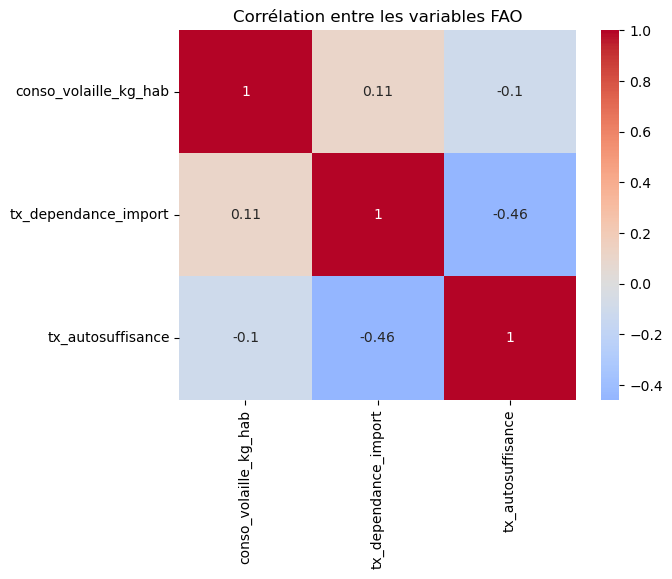

In [65]:
#insertion d'une heatmap pour plus de lisibilité
sns.heatmap(
    dispo_volailles[
        ['conso_volaille_kg_hab', 'tx_dependance_import', 'tx_autosuffisance']
    ].corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title("Corrélation entre les variables FAO")
plt.show()

La consommation de volaille par habitant est faiblement corrélée aux indicateurs de structure de l’offre, ce qui indique que les niveaux de consommation ne dépendent pas directement de la capacité productive ou de la dépendance aux importations. En revanche, le taux d’autosuffisance et le taux de dépendance aux importations présentent une corrélation négative modérée, conforme à l’intuition économique. L’absence de corrélations fortes confirme que les variables retenues apportent des informations complémentaires et peuvent être intégrées conjointement dans l’ACP.

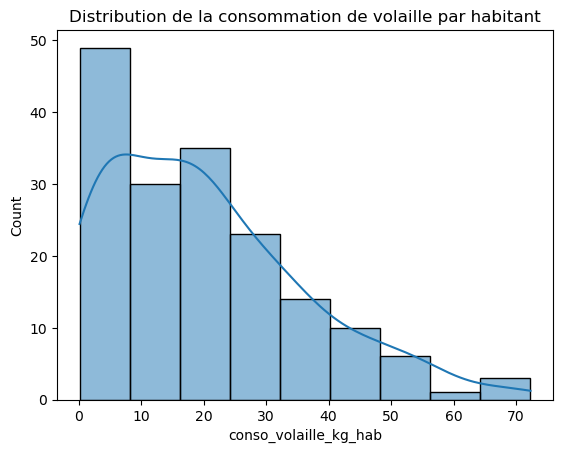

In [66]:
sns.histplot(dispo_volailles['conso_volaille_kg_hab'], kde=True)
plt.title("Distribution de la consommation de volaille par habitant")
plt.show()

La distribution est asymétrique à droite, révélant une forte hétérogénéité des niveaux de consommation entre pays, ce qui justifie une standardisation préalable à l’ACP.

### 2. Jointures 

Toutes mes tables sont prêtes, elles ont toutes pays_code en clé

In [67]:
df_acp = (
    dispo_volailles
    .merge(pib_hab[['pays_code', 'pib_par_hab($)']], on='pays_code', how='left')
    .merge(stabilite_politique[['pays_code', 'stabilite_pol']], on='pays_code', how='left')
    .merge(population[['pays_code','nb_hab']], on='pays_code', how='left')
    .merge(ipl[['pays_code','ind_perf_logistique']], on='pays_code', how='left')
    .merge(conso_energie_renouvelable[['pays_code','conso_energie']], on='pays_code', how='left')
    .merge(acces_elec[['pays_code','acces_electricite']], on='pays_code', how='left')
)

### 3. Préparation à l'ACP

In [68]:
df_acp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pays_code                 171 non-null    object 
 1   pays_FAO                  171 non-null    object 
 2   conso_volaille_kg_hab     171 non-null    float64
 3   Disponibilité intérieure  169 non-null    float64
 4   Importations - Quantité   169 non-null    float64
 5   Production                167 non-null    float64
 6   tx_dependance_import      169 non-null    float64
 7   tx_autosuffisance         167 non-null    float64
 8   pib_par_hab($)            170 non-null    Int64  
 9   stabilite_pol             169 non-null    float64
 10  nb_hab                    171 non-null    int32  
 11  ind_perf_logistique       145 non-null    float64
 12  conso_energie             171 non-null    float64
 13  acces_electricite         171 non-null    float64
dtypes: Int64(1

In [69]:
#je choisis de conserver les 8 variables pour l'ACP
acp = df_acp[[
    'conso_volaille_kg_hab',
    'tx_dependance_import',
    'tx_autosuffisance',
    'pib_par_hab($)',
    'stabilite_pol',
    'ind_perf_logistique',
    'conso_energie',
    'acces_electricite'
]]

In [70]:
acp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   conso_volaille_kg_hab  171 non-null    float64
 1   tx_dependance_import   169 non-null    float64
 2   tx_autosuffisance      167 non-null    float64
 3   pib_par_hab($)         170 non-null    Int64  
 4   stabilite_pol          169 non-null    float64
 5   ind_perf_logistique    145 non-null    float64
 6   conso_energie          171 non-null    float64
 7   acces_electricite      171 non-null    float64
dtypes: Int64(1), float64(7)
memory usage: 11.0 KB


In [71]:
#Je conserve les pays en index 
acp.index = df_acp.loc[acp.index, 'pays_FAO']

In [72]:
acp.head()

,conso_volaille_kg_hab,tx_dependance_import,tx_autosuffisance,pib_par_hab($),stabilite_pol,ind_perf_logistique,conso_energie,acces_electricite
pays_FAO,,,,,,,,
Afghanistan,1.53,50.88,49.12,525,-2.79,1.95,19.5,97.7
Afrique du Sud,35.69,24.27,78.71,6618,-0.28,3.38,7.9,84.4
Albanie,16.36,80.85,27.66,5006,0.37,2.66,36.9,99.9
Algérie,6.38,0.72,99.28,4555,-0.92,2.45,0.1,99.5
Allemagne,19.47,48.42,87.06,45554,0.57,4.20,15.2,100.0


In [73]:
#je supprime les valeurs manquantes 
acp = acp.dropna()
acp.shape

(141, 8)

In [74]:
#je standardise pour mettre toutes les variables a la meme echelle 
scaler = StandardScaler()
acp_scaled = pd.DataFrame(
    scaler.fit_transform(acp),
    columns=acp.columns,
    index=acp.index
)

Les variables présentant des unités et des ordres de grandeur différents, une standardisation a été appliquée afin de garantir une contribution équitable de chaque variable à l’analyse en composantes principales.

In [75]:
print(acp_scaled.mean())
print(acp_scaled.std())

conso_volaille_kg_hab    6.299138e-17
tx_dependance_import    -5.039310e-17
tx_autosuffisance       -2.992090e-17
pib_par_hab($)          -6.929052e-17
stabilite_pol           -5.669224e-17
ind_perf_logistique      3.338543e-16
conso_energie           -5.039310e-17
acces_electricite       -3.779483e-17
dtype: float64
conso_volaille_kg_hab    1.003565
tx_dependance_import     1.003565
tx_autosuffisance        1.003565
pib_par_hab($)           1.003565
stabilite_pol            1.003565
ind_perf_logistique      1.003565
conso_energie            1.003565
acces_electricite        1.003565
dtype: float64


Les variables ont été standardisées afin d’avoir une moyenne nulle et un écart-type unitaire. La vérification des statistiques descriptives confirme la bonne application de cette étape préalable à l’ACP.

In [76]:
#J'importe le df avant standardisation pour garantir reproductibilité, traçabilité et cohérence méthodologique.
acp.to_csv("acp.csv", index=False)
df_acp.to_csv("df_acp.csv", index=False)